In [1]:
#| echo: false
#| output: false

Jupyter Notebook disponível em [https://github.com/psi5892/exercicios_aula_publico/blob/main/pytorch_topicos/pytorch_topicos.ipynb](https://github.com/psi5892/exercicios_aula_publico/blob/main/pytorch_topicos/pytorch_topicos.ipynb)

No Google Colab, é necessário habilitar o suporte à GPU acessando "Change Runtime Type" e selecionando uma opção com GPU como, por exemplo, a "T4 GPU".

_______

O [PyTorch](https://pytorch.org/) é um dos *frameworks* mais utilizados para o treinamento de modelos de aprendizado de máquina. A seguir, são listados os seus principais componentes e é mostrado um exemplo evoluindo de um algoritmo adaptativo implementado em NumPy, incorporando componentes do PyTorch um a um, até chegar em uma implementação clássica do algoritmo usando PyTorch.

Antes disso, vamos carregar as bibliotecas necessárias:

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from scipy import signal
from torch import nn

## 1. Tensores e operações básicas

- Objetos do tipo `torch.Tensor`, semelhantes à *arrays* do NumPy, mas com algumas funções adicionais:
  - Podem ser alocados facilmente na GPU;
  - Possibilidade de cálculo automático de gradientes.
- Ref.: [https://pytorch.org/docs/stable/tensors.html](https://pytorch.org/docs/stable/tensors.html)

- Podem ser criados a partir de listas do Python:

In [3]:
torch.tensor([2, 3, 4])

tensor([2, 3, 4])

- Atributos de *shape* e *rank* semelhantes aos *arrays* do NumPy:

In [4]:
x = torch.tensor([2, 3, 4])
x.shape

torch.Size([3])

In [5]:
x = torch.tensor([[2, 3, 4]])
x.shape

torch.Size([1, 3])

- Tipo padrão para representação de ponto flutuante é o `float32`:

In [6]:
x = torch.tensor([[2., 3., 4.]])
x.dtype

torch.float32

- Funções auxiliares para criação de tensores com zeros, uns, aleatórios e matrizes identidade:

In [7]:
torch.zeros((2, 3))

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [8]:
torch.ones((3, 2))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])

In [9]:
torch.rand(2, 2)

tensor([[0.1822, 0.9239],
        [0.8521, 0.6765]])

In [10]:
torch.randn(3, 3)

tensor([[ 1.7184,  0.7325, -0.2358],
        [ 0.9880,  1.0727, -1.5431],
        [-0.9920,  1.9307, -1.0701]])

In [11]:
torch.eye(3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

- Funções auxiliares para criação de sequências:

In [12]:
torch.linspace(0, 1, 10)

tensor([0.0000, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889,
        1.0000])

In [13]:
torch.arange(10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

- `reshape`e `view`: são semelhantes, mas
  - `view` usa os mesmos dados do tensor original. Não funciona para o caso de dados não contíguos;
  - `reshape` tenta fazer o mesmo que `view`, mas no caso de dados não contíguos, retorna um tensor com uma cópia dos dados originais.
- A sugestão é usar sempre `view`;
- Ref.: [https://stackoverflow.com/questions/49643225/whats-the-difference-between-reshape-and-view-in-pytorch](https://stackoverflow.com/questions/49643225/whats-the-difference-between-reshape-and-view-in-pytorch)

In [14]:
x = torch.rand(4,3)
x

tensor([[0.4120, 0.4468, 0.2359],
        [0.6905, 0.9573, 0.4613],
        [0.5446, 0.4713, 0.2353],
        [0.1008, 0.8624, 0.0569]])

In [15]:
x.view(12, -1)

tensor([[0.4120],
        [0.4468],
        [0.2359],
        [0.6905],
        [0.9573],
        [0.4613],
        [0.5446],
        [0.4713],
        [0.2353],
        [0.1008],
        [0.8624],
        [0.0569]])

In [16]:
x.reshape(12, -1)

tensor([[0.4120],
        [0.4468],
        [0.2359],
        [0.6905],
        [0.9573],
        [0.4613],
        [0.5446],
        [0.4713],
        [0.2353],
        [0.1008],
        [0.8624],
        [0.0569]])

### 1.1 Operações

- Operações aritméticas e matriciais semelhantes às do NumPy;
- PyTorch disponibiliza diversas operações ponto a ponto como `torch.abs()` e `torch.cos()` e diversas operações de redução como `torch.sum()` e `torch.mean()`;
- É importante utilizar as operações do PyTorch para processar os tensores, para que seja possível calcular o gradiente automaticamente com o autograd;
- Além disso, há diversas operações de comparação, espectrais e outras.
- Referência: [https://pytorch.org/docs/stable/torch.html#math-operations](https://pytorch.org/docs/stable/torch.html#math-operations)

### 1.2 Alocação em CPU e em GPU

- Atributo `is_cuda` permite ver se o tensor está alocado na GPU:

In [17]:
x = torch.Tensor([1, 2, 3])

In [18]:
x.is_cuda

False

- Para alocar na GPU, é necessário criar um objeto device e usar o método `.to()`:

In [19]:
device = torch.device("cuda")
x = x.to(device)

In [20]:
x.is_cuda

True

- É possível ver se há GPU disponível com o método `torch.cuda.is_available()`:

In [21]:
torch.cuda.is_available() 

True

- É usual usar a seguinte estrutura para alocação automática de tensores na GPU, quando disponível:

In [22]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
x = x.to(device)

- Para trazer realocar um tensor de volta à CPU, pode-se usar `.cpu()`:

In [23]:
x.is_cuda

True

In [24]:
x = x.cpu()

In [25]:
x.is_cuda

False

- O método `.to()` também é usado para fazer *casting* de tensores:

In [26]:
x.dtype

torch.float32

In [27]:
y = x.to(torch.float64)
y.dtype

torch.float64

### 1.3 Conversão de dados para NumPy e vice-versa

- Um tensor do PyTorch pode ser convertido para um *array* do NumPy usando o método .numpy()`:

In [28]:
x = torch.randn(5,5)
x

tensor([[-0.0475, -0.6951,  0.6743, -1.3640,  0.8516],
        [-0.6072, -1.8393,  0.6060, -1.3986, -0.5471],
        [-1.6266, -1.2548,  0.8110,  0.3843,  0.1896],
        [ 0.5448, -2.7137, -0.5067,  1.8997,  0.8794],
        [ 0.4803,  0.5730,  0.2100, -0.5451,  0.0597]])

In [29]:
x.dtype

torch.float32

In [30]:
x_np = x.numpy()
x_np

array([[-0.04745141, -0.69513506,  0.6742779 , -1.3640411 ,  0.8515677 ],
       [-0.6071822 , -1.8392884 ,  0.6060152 , -1.3985505 , -0.54706645],
       [-1.6265795 , -1.254808  ,  0.8110163 ,  0.3843195 ,  0.18963134],
       [ 0.5448107 , -2.713655  , -0.50672483,  1.8996508 ,  0.87941235],
       [ 0.4803328 ,  0.5729542 ,  0.21001685, -0.54511493,  0.05966017]],
      dtype=float32)

In [31]:
x_np.dtype

dtype('float32')

- `torch.Tensor` pode criar um tensor PyTorch a partir de um *array* do NumPy, mas é necessário atenção à precisão numérica:

In [32]:
x_np = np.random.randn(5,5)
x_np

array([[-1.37809662, -0.07378015, -0.86446831,  1.20265543, -1.25361983],
       [-0.14066389, -0.58857184,  1.33793313,  1.12732479, -0.87137573],
       [ 0.19232294,  0.13298185,  0.98717105,  0.8995655 ,  0.15003134],
       [ 0.20407629, -0.64705029, -1.55628302,  0.63332911, -0.89715297],
       [ 0.53191555,  0.56665046,  2.27974678,  0.60181584,  0.23895466]])

In [33]:
x_np.dtype

dtype('float64')

In [34]:
x = torch.Tensor(x_np,)
x

tensor([[-1.3781, -0.0738, -0.8645,  1.2027, -1.2536],
        [-0.1407, -0.5886,  1.3379,  1.1273, -0.8714],
        [ 0.1923,  0.1330,  0.9872,  0.8996,  0.1500],
        [ 0.2041, -0.6471, -1.5563,  0.6333, -0.8972],
        [ 0.5319,  0.5667,  2.2797,  0.6018,  0.2390]])

In [35]:
x.dtype

torch.float32

- A função `torch.from_numpy` preserva o tipo do *array* NumPy:

In [36]:
x2 = torch.from_numpy(x_np)
x2.dtype

torch.float64

## 2. Autograd

- Tensores com o atributo `requires_grad=True` têm o gradiente calculado automaticamente;
- Só vetores do tipo `float` ou `complex` podem usar `requires_grad=True`.

In [37]:
x0 = torch.tensor([1., 2., 3.], requires_grad=True)
x0

tensor([1., 2., 3.], requires_grad=True)

In [38]:
x1 = torch.tensor([4., 5., 6.], requires_grad=True)
x1

tensor([4., 5., 6.], requires_grad=True)

- Tensores criados a partir de outros com `requires_grad=True` também têm `requires_grad=True`:

In [39]:
f = torch.sum(x0**2 + x1)

In [40]:
f.requires_grad

True

- Tensores criados pelo usuário são *leaf nodes* no grafo, identificados pelo atributo `is_leaf`:

In [41]:
x0.is_leaf

True

In [42]:
x1.is_leaf

True

In [43]:
f.is_leaf

False

- Gradiente de `f` em relação `x0` e `x1`:

$
\frac{\partial f}{\partial \mathbf{x}} = 
\left[
\begin{matrix}
\frac{\partial f}{\partial x_0}\\
\frac{\partial f}{\partial x_1}\\
\end{matrix}
\right] = 
\left[
\begin{matrix}
2x_0\\
1\\
\end{matrix}
\right]
$

- Os gradientes são armazenados no atributo `grad`, inicialmente igual a `None`:

In [44]:
x0.grad is None

True

In [45]:
x1.grad is None

True

- Para que os gradientes sejam calculados, é necessário executar o método `.backward()` do nó em relação ao qual se deseja calculá-los:

In [46]:
f.backward()

In [47]:
x0.grad

tensor([2., 4., 6.])

In [48]:
x0

tensor([1., 2., 3.], requires_grad=True)

In [49]:
x1.grad

tensor([1., 1., 1.])

In [50]:
x1

tensor([4., 5., 6.], requires_grad=True)

## 3. Do NumPy ao PyTorch

A seguir, serão apresentados os principais elementos do PyTorch, partindo de um exemplo de treinamento de um modelo com o LMS implementado com o NumPy. Serão abordados:
- Uso de tensores PyTorch;
- Uso do autograd;
- Blocos para função custo;
- Blocos para otimizadores;
- Uso de objetos representando modelos PyTorch;
- Uso de blocos PyTorch para a composição de modelos.

As mudanças no código serão indicadas por comentários.

### 3.1 Começando pelo NumPy

- Código para treinamento de um modelo com o LMS para identificação de sistemas:

In [51]:
N = 500
M = 3
sigmav2 = 0.01
eta = 0.1

x = np.random.randn(N, 1)
wo = np.array([[0.1, 0.2, 0.3]])
d = signal.lfilter(wo.squeeze(), 1, x.squeeze()) + np.sqrt(sigmav2) * np.random.randn(N)
d = d.reshape(-1, 1)

In [52]:
def lms(x, d, eta, M):
    N = len(x)
    xM = np.zeros((M, 1))
    wi = np.zeros((1, M))    
    y = np.zeros((N, 1))
    e = np.zeros((N, 1))
    w = np.zeros((N + 1, M))
    
    for i in range(N):
        xM = np.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        ei = d[i] - yi
        wi = wi + eta/2 * 2 * ei * xM.T
        y[i] = yi
        e[i] = ei
        w[i + 1, :] = wi
    return y, e, w

In [53]:
(y_lms, e_lms, w_lms) = lms(x, d, eta, M)

- Vamos comparar a evolução dos pesos, usando a seguinte função:

In [54]:
def plot_ws(w, w_lms):
    plt.figure()
    plt.plot(w, "b")
    plt.plot(w_lms, "k", linewidth=5, alpha=0.5)
    plt.xlabel("iterações")
    plt.ylabel("coeficientes")
    plt.grid()

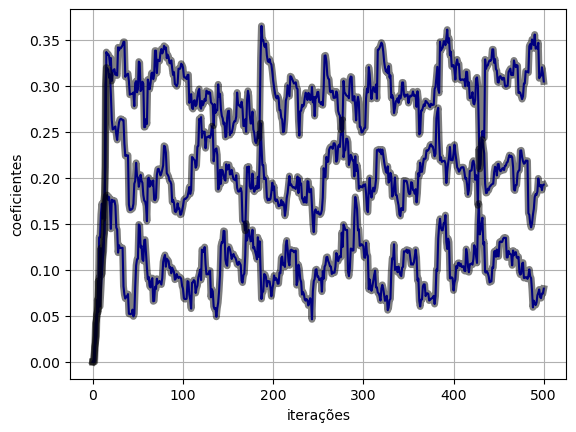

In [55]:
plot_ws(w_lms, w_lms)

### 3.2 Uso de tensores PyTorch

- Para manter a precisão numérica padrão do NumPy, vamos configurar o PyTorch para usar tensores do tipo `float64`:

In [56]:
torch.set_default_dtype(torch.float64)

- A forma de uso dos tensores PyTorch é bem semelhante à dos *arrays* NumPy. Na maioria dos casos, basta trocar a chamada `np.` por `torch.`:

In [57]:
x = torch.tensor(x)
wo = torch.tensor(wo)
d = torch.tensor(d)

In [58]:
def lms_torch(x, d, eta, M):
    N = len(x)
    
    # xM = np.zeros((M, 1))
    # wi = np.zeros((1, M))
    # y = np.zeros((N, 1))
    # e = np.zeros((N, 1))
    # w = np.zeros((N + 1, M))
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M))
    y = torch.zeros((N, 1))
    e = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)
    
    for i in range(N):
        
        # xM = np.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        
        yi = wi @ xM
        ei = d[i] - yi
        wi = wi + eta/2 * 2 * ei * xM.T
        y[i] = yi
        e[i] = ei
        w[i + 1, :] = wi
    return y, e, w

In [59]:
(y_torch, e_torch, w_torch) = lms_torch(x, d, eta, M)

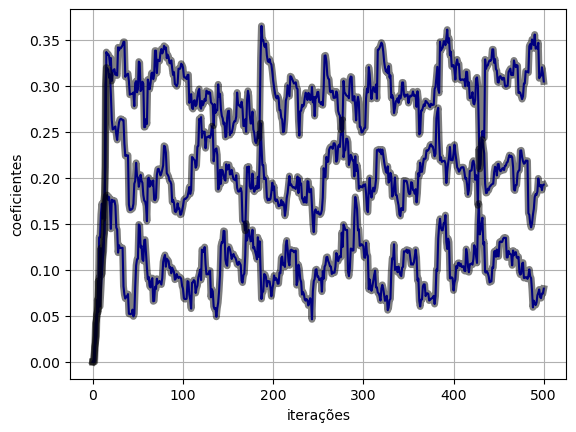

In [60]:
plot_ws(w_torch.numpy(), w_lms)

### 3.3 Uso do autograd

- Tensores que necessitam do cálculo do gradiente, devem ter o atributo `requires_grad=True`;
- Gradientes são calculados utilizando o método `.backward()` chamado no objeto que representa o nó em relação ao qual desejamos calcular os gradientes;
- É necessário tomar cuidado com operações para as quais não queremos calcular o gradiente. Nesses casos, utilizamos o bloco de contexto `with torch.no_grad():`;
- Note que é importante não sobrescrever o objeto `wi` para que os gradientes sejam computados corretamente (uso de `wi[:] = (...)`);
- A cada chamada de `.backward()`, os valores dos gradientes são acumulados nos atributos `.grad` de cada parâmetro do modelo;
  - Dessa forma, é necessário zerar os gradientes a cada iteração, usando o método `.grad.zero_()`.

In [61]:
def lms_torch_autograd(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))

    # wi = torch.zeros((1, M))
    wi = torch.zeros((1, M), requires_grad=True)

    y = torch.zeros((N, 1))
    e = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        ei = d[i] - yi        

        # Novo
        mse = ei**2
        mse.backward()

        # wi = wi + eta/2 * 2 * ei * xM.T
        # y[i] = yi
        # e[i] = ei
        # w[i + 1, :] = wi
        with torch.no_grad():            
            wi[:] = wi[:] - eta/2 * wi.grad
            y[i] = yi
            e[i] = ei
            w[i + 1, :] = wi

        # Novo    
        wi.grad.zero_()
        
    return y, e, w

In [62]:
(y_torch_autograd, e_torch_autograd, w_torch_autograd) = lms_torch_autograd(x, d, eta, M)

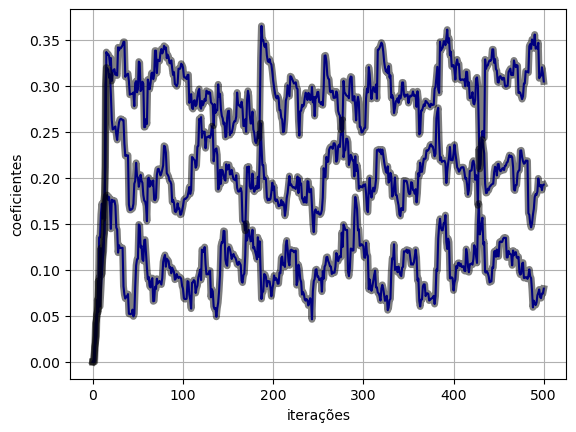

In [63]:
plot_ws(w_torch_autograd.numpy(), w_lms)

### 3.4 Blocos para função custo

- O PyTorch disponibiliza diversos blocos para a representação de funções custo: [https://pytorch.org/docs/stable/nn.html#loss-functions](https://pytorch.org/docs/stable/nn.html#loss-functions);
- Para o caso da função custo MSE, utilizamos o bloco `nn.MSELoss`.

In [64]:
def lms_torch_loss(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M), requires_grad=True)
    y = torch.zeros((N, 1))
    
    #e = torch.zeros((N, 1))
    
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    # Novo
    loss_function = nn.MSELoss()
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM

        #ei = d[i] - yi
        #mse = ei**2
        #mse.backward()
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
    
        with torch.no_grad():            
            wi[:] = wi[:] - eta/2 * wi.grad
            y[i] = yi
            losses[i] = loss
            w[i + 1, :] = wi
        wi.grad.zero_()
    return y, loss, w

In [65]:
(y_torch_loss, e_torch_loss, w_torch_loss) = lms_torch_loss(x, d, eta, M)

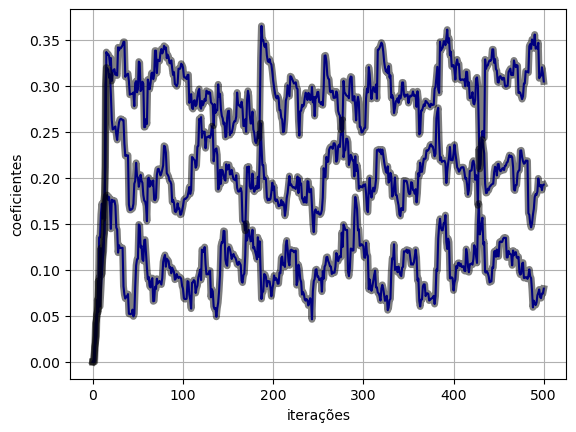

In [66]:
plot_ws(w_torch_loss.numpy(), w_lms)

### 3.5 Blocos para otimizadores

- O PyTorch disponibiliza diversos blocos para a representação de otimizadores: [https://pytorch.org/docs/stable/optim.html#algorithms](https://pytorch.org/docs/stable/optim.html#algorithms);
- Para o caso do otimizador com o algoritmo *backpropagation* tradicional, chamado de *Stochastic Gradient Descent*, utilizamos o bloco `nn.SGD`;
- A atualização dos pesos do otimizador é feita chamando o método `.step()`.


In [67]:
def lms_torch_optim(x, d, eta, M):
    N = len(x)
    xM = torch.zeros((M, 1))
    wi = torch.zeros((1, M), requires_grad=True)
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()

    # Novo
    optimizer = torch.optim.SGD([wi], lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        yi = wi @ xM
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()

        # Novo
        optimizer.step()
    
        with torch.no_grad():            
            
            # wi[:] = wi[:] - eta/2 * wi.grad
            
            y[i] = yi
            losses[i] = loss
            w[i + 1, :] = wi
        wi.grad.zero_()
    return y, loss, w

In [68]:
(y_torch_optim, e_torch_optim, w_torch_optim) = lms_torch_optim(x, d, eta, M)

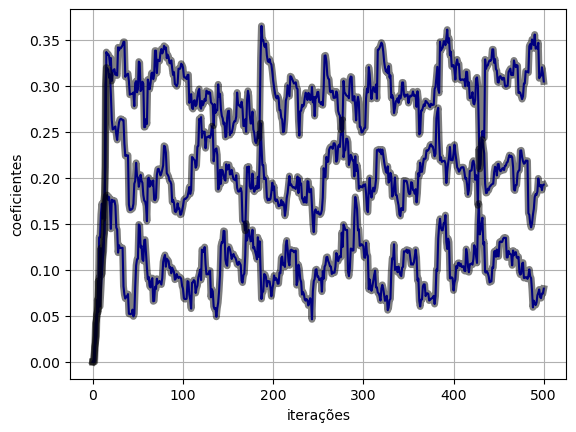

In [69]:
plot_ws(w_torch_optim.numpy(), w_lms)

### 3.6 Uso de objetos representando modelos PyTorch

- Os modelos PyTorch são construídos com a definição de classes que herdam de `nn.module`;
- No método `__init__()`, devem ser criados os elementos que compõem o modelo. Nesse caso, vamos utilizar apenas um objeto representando parâmetros genéricos;
- O método `forward()` define como é calculada a saída a partir da entrada, nesse caso chamada de `xM`;
- Após a criação da classe, instancia-se um objeto para representar o modelo;
  - A saída do modelo é calculada utilizando este objeto.
- Assim como feito anteriormente, é necessário zerar os gradientes do modelo a cada iteração;
  - É usual fazer isso no início do loop de treinamento.

In [70]:
# Novo
class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.wi = nn.Parameter(torch.zeros((1, M), requires_grad=True))
        
    def forward(self, xM):
        output = self.wi @ xM
        return output

# Novo
model = LMS()

# def lms_torch_model(x, d, eta, M):
def lms_torch_model(x, d, eta, M, model):

    N = len(x)
    xM = torch.zeros((M, 1))
    
    # wi = torch.zeros((1, M), requires_grad=True)
    
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()

    #optimizer = torch.optim.SGD([wi], lr=eta/2)
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))

        # yi = wi @ xM
        model.zero_grad()
        yi = model(xM)

        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss
            w[i + 1, :] = model.wi.clone()

        # wi.grad.zero_()        
    
    return y, loss, w

In [71]:
(y_torch_model, e_torch_model, w_torch_model) = lms_torch_model(x, d, eta, M, model)

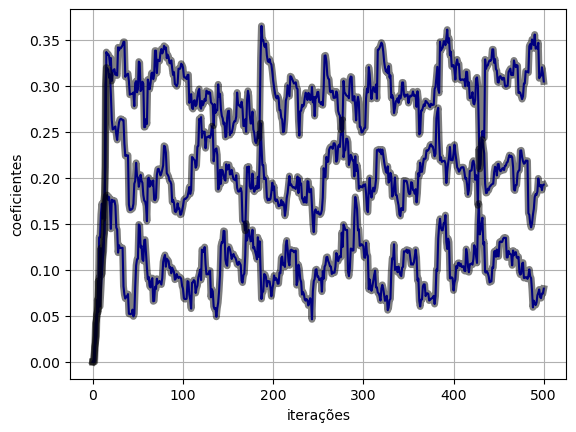

In [72]:
plot_ws(w_torch_model.numpy(), w_lms)

### 3.7 Uso de blocos PyTorch para a composição de modelos

- No último exemplo, construímos um modelo PyTorch baseado em um conjunto de parâmetros configurados com `nn.Parameter`.
  - No entanto, o PyTorch conta com inúmeros blocos para a composição de modelos como blocos lineares e funções de ativação para a composição de camadas de redes MLP;
  - Ref.: [https://pytorch.org/docs/stable/nn.html](https://pytorch.org/docs/stable/nn.html).
- No caso do LMS, podemos utilizar o bloco `nn.Linear`.

In [73]:
# class LMS(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.wi = nn.Parameter(torch.zeros((1, M), requires_grad=True))
        
#     def forward(self, xM):
#         output = self.wi @ xM
#         return output

class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(M, 1, bias=False)        
        
    def forward(self, x):
        output = self.l1(x.squeeze())
        return output

model = LMS()

def lms_torch_model_2(x, d, eta, M, model):
    N = len(x)
    xM = torch.zeros((M, 1))
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        model.zero_grad()
        yi = model(xM)
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss

            # w[i + 1, :] = model.wi.clone()
            w[i + 1, :] = model.l1.weight.clone()

    return y, loss, w

In [74]:
(y_torch_model_2, e_torch_model_2, w_torch_model_2) = lms_torch_model_2(x, d, eta, M, model)

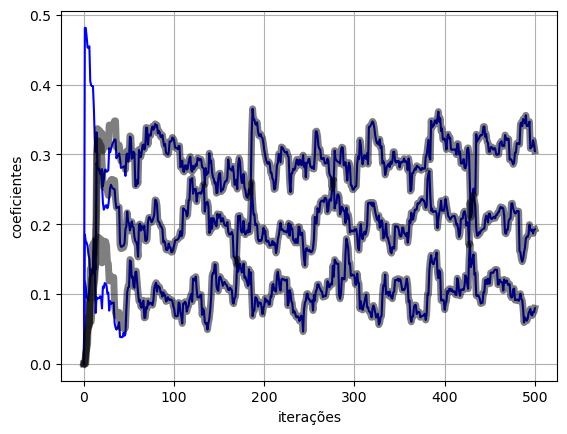

In [75]:
plot_ws(w_torch_model_2.numpy(), w_lms)

- As curvas de evolução dos pesos não coincidem com as anteriores, neste caso.
  - Isso ocorre por conta da inicialialização dos pesos utilizada pelo bloco `nn.Linear`que não são inicializados com zeros, conforme descrito na [documentação](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).
- Para obter o mesmo comportamento, é necessário inicializar os pesos com zeros:

In [76]:
class LMS(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(M, 1, bias=False)

    def forward(self, x):
        output = self.l1(x.squeeze())
        return output

# Novo
def weights_init(m):
    classname = m.__class__.__name__    
    if classname.find('Linear') != -1:
        if m.weight is not None:
            #torch.nn.init.xavier_normal_(m.weight)
            torch.nn.init.zeros_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model = LMS()

# Novo
model.apply(weights_init)


def lms_torch_model_3(x, d, eta, M, model):
    N = len(x)
    xM = torch.zeros((M, 1))
    y = torch.zeros((N, 1))
    losses = torch.zeros((N, 1))
    w = torch.zeros(N + 1, M)

    loss_function = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=eta/2)
    
    for i in range(N):
        xM = torch.vstack((x[i : i + 1, [0]], xM[0 : M - 1, [0]]))
        model.zero_grad()
        yi = model(xM)
        loss = loss_function(yi.squeeze(), d[i].squeeze())
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():            
            y[i] = yi
            losses[i] = loss            
            w[i + 1, :] = model.l1.weight.clone()
    return y, loss, w

In [77]:
(y_torch_model_3, e_torch_model_3, w_torch_model_3) = lms_torch_model_3(x, d, eta, M, model)

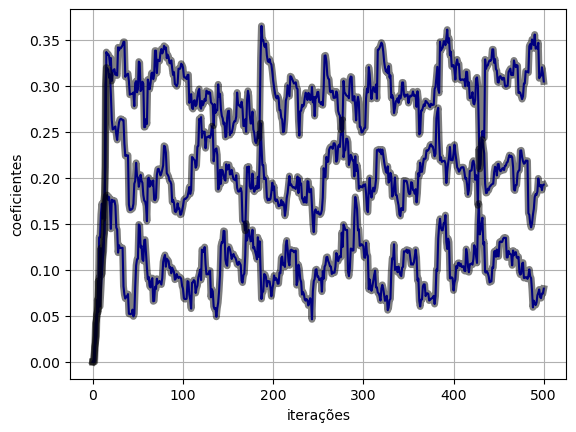

In [78]:
plot_ws(w_torch_model_3.numpy(), w_lms)